Cut the $P(M_{\rm{UV}}|M_h)$ distribution at a physical minimimum $M_{\rm{UV}}$

In [5]:
from escripts import eMCMC
from escripts import edata
from escripts import eplots
import zeus21
from scipy.special import erf
import zeus21

In [6]:
file_names = ['/Users/eb35267/Desktop/code/home/data/Bouwens2021_low_z.txt',
              '/Users/eb35267/Desktop/code/home/data/Donnan24_limit_z.txt',
             '/Users/eb35267/Desktop/code/home/data/Chemerynska+25.txt',
             '/Users/eb35267/Desktop/code/home/data/Donnan24_high_z.txt',
             '/Users/eb35267/Desktop/code/home/data/Kokorev+25.txt',
             '/Users/eb35267/Desktop/code/home/data/Weibel+25_upper_limits.txt']
data_labels = ['Bouwens+21', 'Donnan+24', 'Chemerynska+25', r'Donnan+24 ultra high-$z$', 'Kokorev+25', 'Weibel+25']
include = [True, True, False, False, False, False]
sorted_data = edata.get_sorted(file_names, data_labels, include_in_likelihood=include)

In [7]:
params = eMCMC.build_param_data({'beta': {'fit':False, 'value': -0.54}, 'dbetadz': {'fit': False, 'value':0}})

In [12]:
importlib.reload(eMCMC)

<module 'escripts.eMCMC' from '/Users/eb35267/Desktop/code/home/escripts/eMCMC.py'>

In [13]:
my_UVLF = eMCMC.UVLF(sorted_data, params)

In [10]:
best_fit = [0.88, 0.06, 11.7, 0, -0.98, -0.05, 0.18, 0.17, -0.89]

In [5]:
def calc_min_MUV(Mh, t, fb, kappaUV = 1.15e-28 # This is taken from what Zeus has it as
    ):
    """
    Mh in M_sun
    t in years
    """
    max_SFR = Mh*fb/t
    # All taken from Zeus:
    LUV = max_SFR/kappaUV
    MUV = 51.63 - 2.5 * np.log10(LUV) #AB magnitude
    return MUV


NameError: name 'fb' is not defined

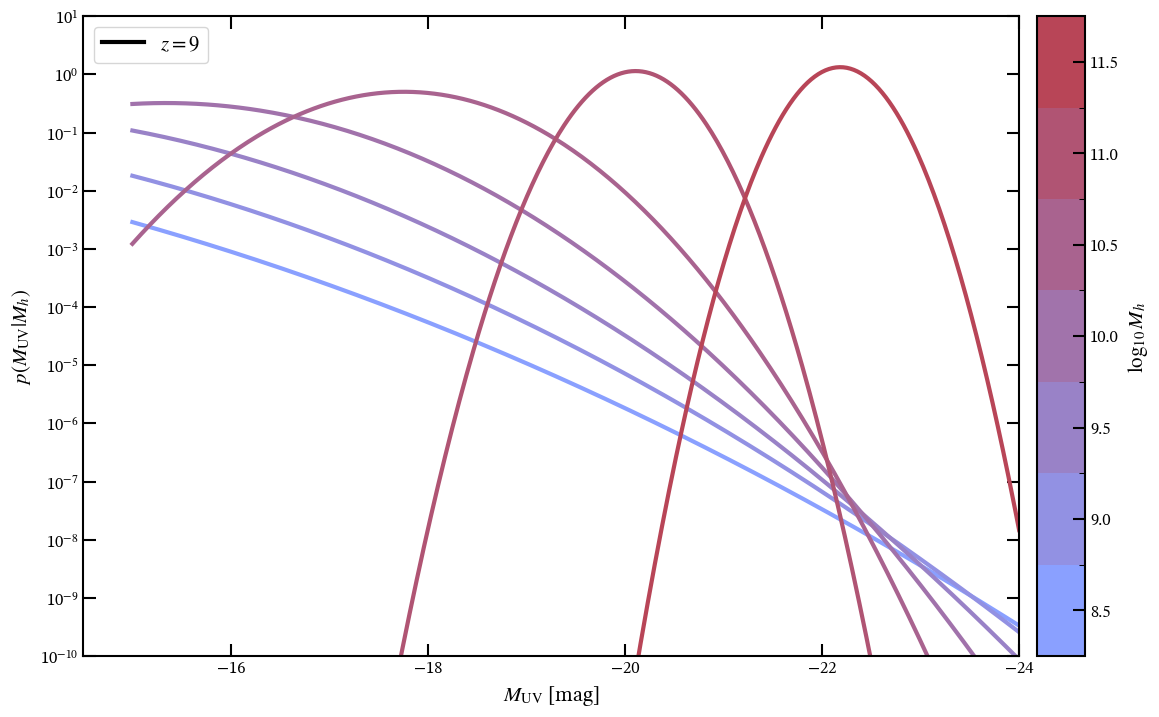

In [7]:
Mhtab = np.arange(8.5, 12, 0.5)
cmap, sm, boundaries = eplots.create_custom_colorbar([eplots.periwinkle, eplots.red], Mhtab)

PMUV_fig, PMUV_ax = eplots.PMUV(my_UVLF, zs = [9], param_values = best_fit, Mhtab = Mhtab, logscale = True)
PMUV_ax.set_ylim(1e-10, 1e1)
PMUV_ax.set_xlim(-14.5, -24)

for Mh in Mhtab:
    min_MUV_t1 = calc_min_MUV(10**Mh, 5e6, fb)
    min_MUV_t2 = calc_min_MUV(10**Mh, 10e6, fb)
    frac = (Mh - Mhtab.min()) / (Mhtab.max() - Mhtab.min()) 
    color = cmap(frac)
    PMUV_ax.axvline(min_MUV_t1, color = color, ls = 'dashed', lw = 2)
    PMUV_ax.axvline(min_MUV_t2, color = color, ls = 'dotted', lw = 3)

PMUV_ax.axvline(0, ls = 'dashed', lw = 2, color = 'black', label = r'$\min(M_{\rm{UV}}|M_h)$, $t = 5$ Myr')
PMUV_ax.axvline(0, ls = 'dotted', lw = 3, color = 'black', label = r'$\min(M_{\rm{UV}}|M_h)$, $t = 10$ Myr')
PMUV_ax.legend()

In [ ]:
# PMUV_fig.savefig('/Users/eb35267/Desktop/code/home/figures/cutoff_visualization.png', bbox_inches='tight')

In [18]:
my_UVLF = eMCMC.UVLF(sorted_data, params, min_t = 50e6)

/Users/eb35267/Desktop/code/repos/Zeus21/zeus21/UVLFs.py:33: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude
/Users/eb35267/Desktop/code/home/escripts/eplots.py:230: RuntimeWarning: divide by zero encountered in log10
  ax.vlines(xdat, np.clip(np.log10(ydat - yerr_lower), -100, 100), np.clip(np.log10(ydat + yerr_upper), -100, 100), ls = '-', colors = navy, linewidth =5)
/Users/eb35267/Desktop/code/repos/Zeus21/zeus21/UVLFs.py:33: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude
/Users/eb35267/Desktop/code/home/escripts/eplots.py:230: RuntimeWarning: divide by zero encountered in log10
  ax.vlines(xdat, np.clip(np.log10(ydat - yerr_lower), -100, 100), np.clip(np.log10(ydat + yerr_upper), -100, 100), ls = '-', colors = navy, linewidth =5)
/Users/eb35267/Desktop/code/repos/Zeus21/zeus21/UVLFs.py:33: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.

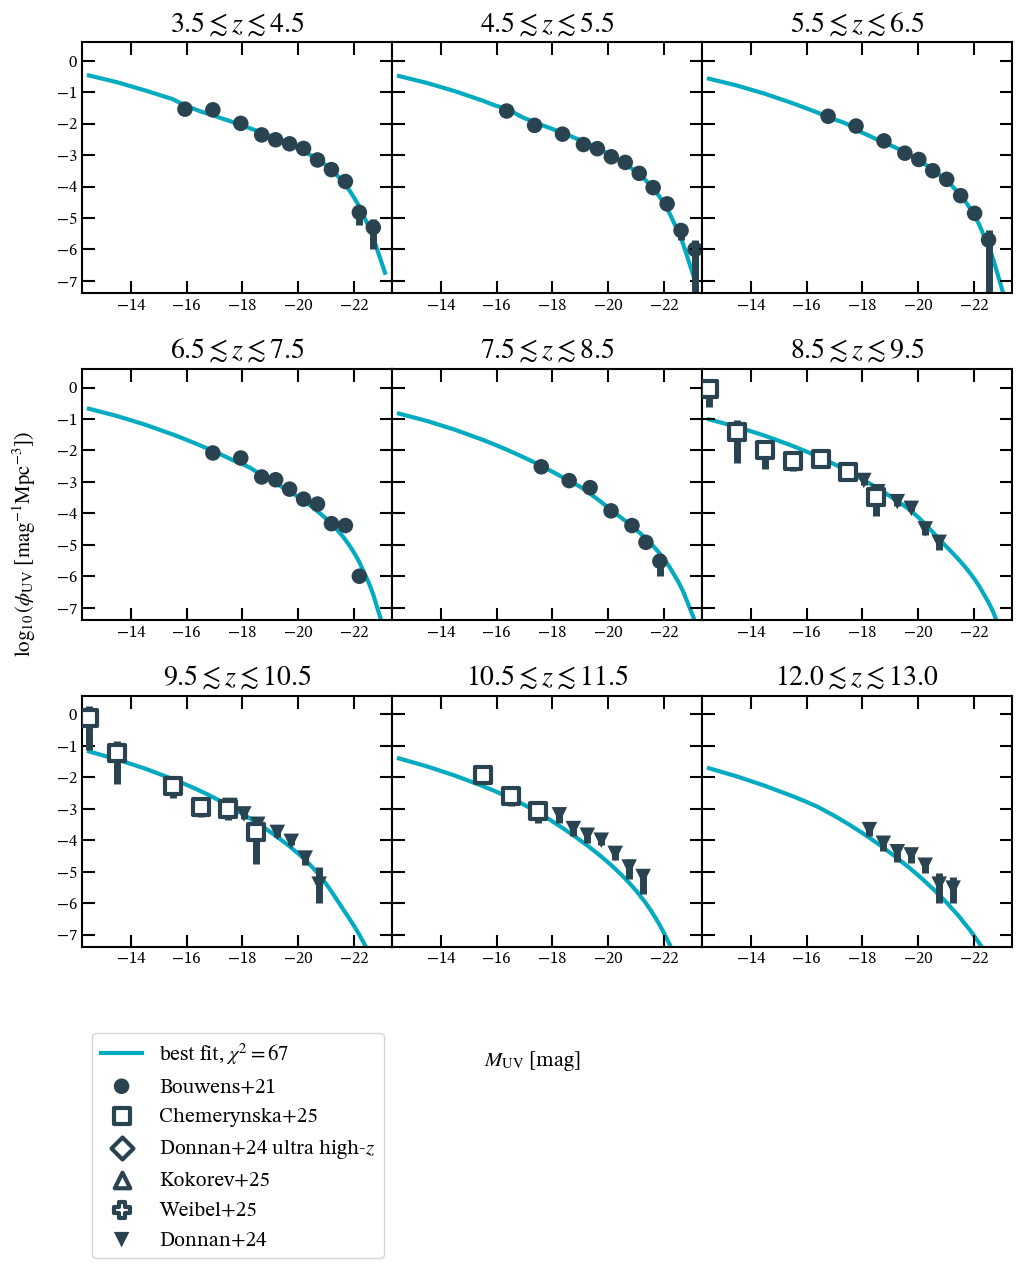

In [19]:
ev_fig = eplots.evolving_UVLF_fit(my_UVLF, plot_from_chain = False, comparison_fits = [best_fit], comparison_labels = ['best fit'])

In [49]:
all_xdat = np.concatenate([
        np.concatenate([ds[2] for ds in z_separated])
        for z_separated in my_UVLF.sorted_data
    ])
    
all_xerr = np.concatenate([
    np.concatenate([ds[6] for ds in z_separated])
    for z_separated in my_UVLF.sorted_data
])

# Get unique x values and their corresponding errors
MUVcenters, xdat_inds = np.unique(all_xdat, return_index=True)
MUVwidths = all_xerr[xdat_inds]

In [66]:
def UVLF_binned(my_UVLF, best_fit, zcenter, zwidth, MUVcenters, MUVwidths, min_MUV, DUST_FLAG=True, RETURNBIAS = False):
    'Binned UVLF in units of 1/Mpc^3/mag, for bins at <zcenter> with a Gaussian width zwidth, centered at MUV centers with tophat width MUVwidths. z width only in HMF since that varies the most rapidly. If flag RETURNBIAS set to true it returns number-avgd bias instead of UVLF, still have to divide by UVLF'
    
    params = my_UVLF.time_evolution(best_fit, zcenter)
    Astro_Parameters = my_UVLF.param_wrapper(params)
    Cosmo_Parameters = my_UVLF.CosmoParams
    HMF_interpolator = my_UVLF.HMFintclass


    #---------
    if(zeus21.constants.NZ_TOINT>1):
        DZ_TOINT = np.linspace(-np.sqrt(zeus21.constants.NZ_TOINT/3.),np.sqrt(zeus21.constants.NZ_TOINT/3.),zeus21.constants.NZ_TOINT) #in sigmas around zcenter
    else:
        DZ_TOINT = np.array([0.0])
    WEIGHTS_TOINT = np.exp(-DZ_TOINT**2/2.)/np.sum(np.exp(-DZ_TOINT**2/2.)) #assumed Gaussian in z, fair



    
    SFRlist = zeus21.sfrd.SFR_II(Astro_Parameters,Cosmo_Parameters,HMF_interpolator, HMF_interpolator.Mhtab, zcenter, zcenter)
    sigmaUV = Astro_Parameters.sigmaUV
    
    if (zeus21.constants.FLAG_RENORMALIZE_LUV == True): #lower the LUV (or SFR) to recover the true avg, not log-avg
        SFRlist/= np.exp((np.log(10)/2.5*sigmaUV)**2/2.0)
        
    MUVbarlist = zeus21.UVLFs.MUV_of_SFR(SFRlist, Astro_Parameters._kappaUV) #avg for each Mh
    MUVbarlist = np.fmin(MUVbarlist,zeus21.constants._MAGMAX)
    

    if(RETURNBIAS==True): # weight by bias) 
        biasM = np.array([bias_Tinker(Cosmo_Parameters, HMF_interpolator.sigma_int(HMF_interpolator.Mhtab,zcenter+dz*zwidth)) for dz in DZ_TOINT])
    else: # do not weight by bias
        biasM = np.ones_like(WEIGHTS_TOINT)
 
        
    HMFtab = np.array([HMF_interpolator.HMF_int(HMF_interpolator.Mhtab,zcenter+dz*zwidth) for dz in DZ_TOINT])
    HMFcurr = np.sum(WEIGHTS_TOINT * HMFtab.T * biasM.T,axis=1)

    #cannot directly 'dust' the theory since the properties of the IRX-beta relation are calibrated on observed MUV. Recursion instead:
    currMUV = MUVbarlist # currMUV is new MUVbar once dust has been applied
    if(DUST_FLAG==True):
        currMUV2 = np.ones_like(currMUV)
        while(np.sum(np.abs((currMUV2-currMUV)/currMUV)) > 0.02):
            currMUV2 = currMUV
            currMUV = MUVbarlist + zeus21.UVLFs.AUV(Astro_Parameters,zcenter,currMUV)

    
    MUVcuthi = MUVcenters +  MUVwidths/2.
    MUVcutlo = MUVcenters -  MUVwidths/2.
    
    xhi = np.subtract.outer(MUVcuthi, currMUV)/(np.sqrt(2) * sigmaUV)
    xlo = np.subtract.outer(MUVcutlo, currMUV )/(np.sqrt(2) * sigmaUV)


    n_std = (min_MUV - currMUV)/(np.sqrt(2) * sigmaUV)

    print(n_std)

    weights_og = (erf(xhi) - erf(xlo)).T/(2.0 * MUVwidths)

    xhi = np.fmax(xhi, n_std)
    xlo = np.fmax(xlo, n_std)

    weights_raw = (erf(xhi) - erf(xlo)).T/(2.0 * MUVwidths)
    weights_renorm = weights_raw/ (0.5*(1-erf(n_std)))[:,None]

    UVLF_filtered = np.trapz(weights_renorm.T * HMFcurr, HMF_interpolator.Mhtab, axis=-1)

    if(Astro_Parameters.USE_POPIII==False):
        return UVLF_filtered, weights_og, weights_renorm
    else:
        _J21interptemp = interp1d(np.linspace(0,100,3), np.zeros(3), kind = 'linear', bounds_error = False, fill_value = 0,) #TODO: how to deal with J21, requires running get_21_coefficients
        SFRlist_III = SFR_III(Astro_Parameters, Cosmo_Parameters, HMF_interpolator, HMF_interpolator.Mhtab, _J21interptemp, zcenter, zcenter, Cosmo_Parameters.vcb_avg)
    
        MUVbarlist_III = MUV_of_SFR(SFRlist_III, Astro_Parameters._kappaUV_III) #avg for each Mh
        MUVbarlist_III = np.fmin(MUVbarlist_III,constants._MAGMAX)
          
        #and the same for popIII, TODO: ignore dust for pop3 for now
        xhi = np.subtract.outer(MUVcuthi, MUVbarlist_III)/(np.sqrt(2) * sigmaUV)
        xlo = np.subtract.outer(MUVcutlo, MUVbarlist_III)/(np.sqrt(2) * sigmaUV)
        weights = (erf(xhi) - erf(xlo)).T/(2.0 * MUVwidths)

        UVLF_filtered_III = np.trapz(weights.T * HMFcurr, HMF_interpolator.Mhtab, axis=-1)
    
        return UVLF_filtered, UVLF_filtered_III

In [31]:
importlib.reload(eplots)

<module 'escripts.eplots' from '/Users/eb35267/Desktop/code/home/escripts/eplots.py'>

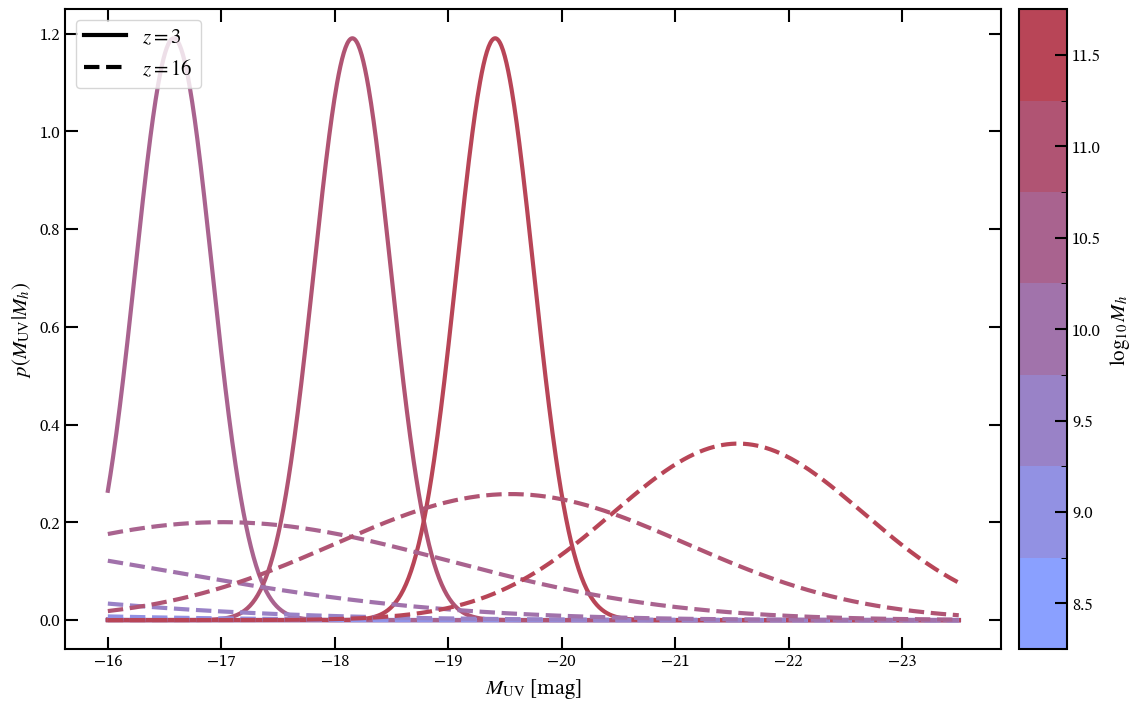

In [51]:
Mhtab = np.arange(8.5, 12, 0.5)
MUV_range = np.linspace(-16, -23.5, 1000)
PMUV_fig = eplots.PMUV(my_UVLF, best_fit, Mhtab, zs = [3, 16], MUVcenters = MUV_range)

In [3]:
min_MUV_5 = calc_min_MUV(my_UVLF.HMFintclass.Mhtab, 5e6, fb)
min_MUV_10 = calc_min_MUV(my_UVLF.HMFintclass.Mhtab, 10e6, fb)

min_const = np.full_like(my_UVLF.HMFintclass.Mhtab, -20)

NameError: name 'calc_min_MUV' is not defined

In [67]:
test_5, weights_og, weights_5 = UVLF_binned(my_UVLF, best_fit, 9, 0.5, MUVcenters, MUVwidths, min_MUV_5)
# test_10, _, weights_10 = UVLF_binned(my_UVLF, best_fit, 9, 0.5, MUVcenters, MUVwidths, min_MUV_10)

# test_const, _, weights_const = UVLF_binned(my_UVLF, best_fit, 9, 0.5, MUVcenters, MUVwidths, min_const)

[-1.55317929e+05 -1.58437518e+05 -1.61557106e+05 -1.64676695e+05
 -1.67796284e+05 -1.70915872e+05 -1.74035461e+05 -1.77155050e+05
 -1.80274639e+05 -1.83394227e+05 -1.86513816e+05 -1.89633405e+05
 -1.71126899e+05 -1.48559005e+05 -1.32547702e+05 -1.20903645e+05
 -1.12168552e+05 -1.05371089e+05 -3.48817084e+00 -3.51889685e+00
 -3.57588119e+00 -3.65630867e+00 -3.75943537e+00 -3.88635106e+00
 -4.04000075e+00 -4.22549750e+00 -4.45083716e+00 -4.72826714e+00
 -5.07684913e+00 -5.52739539e+00 -6.13249529e+00 -6.98840655e+00
 -8.28789543e+00 -1.04692782e+01 -1.47568443e+01 -1.68353708e+01
 -1.65430002e+01 -1.63783375e+01 -1.63757516e+01 -1.65486586e+01
 -1.68817777e+01 -1.73398491e+01 -1.78838454e+01 -1.84818932e+01
 -1.91120455e+01 -1.97606163e+01 -2.04195437e+01 -2.10842284e+01
 -2.17520935e+01 -2.24217093e+01 -2.30922871e+01 -2.37633928e+01]


/Users/eb35267/Desktop/code/repos/Zeus21/zeus21/UVLFs.py:33: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude


<>:12: SyntaxWarning: invalid escape sequence '\l'
<>:12: SyntaxWarning: invalid escape sequence '\l'
/var/folders/mm/m_9lg4t966qdjwf1r__0773r0000gq/T/ipykernel_53788/414175105.py:12: SyntaxWarning: invalid escape sequence '\l'
  ax.set_title(f'$\log(M_h) = {round(np.log10(my_UVLF.HMFintclass.Mhtab)[i], 2)}$')


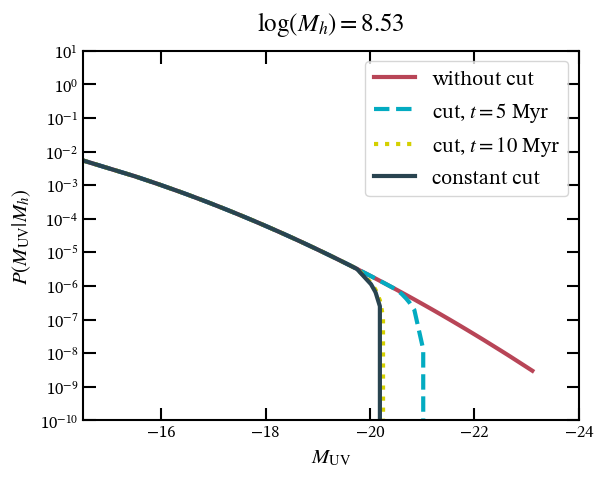

In [61]:
i = 20

fig, ax = plt.subplots()
ax.set_ylabel(r'$P(M_{\rm{UV}}|M_h)$')
ax.set_xlabel(r'$M_{\rm{UV}}$')
ax.plot(MUVcenters, weights_og[i], label = 'without cut')
ax.plot(MUVcenters, weights_5[i], label = r'cut, $t=5$ Myr')
ax.plot(MUVcenters, weights_10[i], label = r'cut, $t=10$ Myr')
ax.plot(MUVcenters, weights_const[i], label = r'constant cut')
ax.invert_xaxis()

ax.set_title(f'$\log(M_h) = {round(np.log10(my_UVLF.HMFintclass.Mhtab)[i], 2)}$')

ax.legend()

ax.set_ylim(1e-10, 1e1)
ax.set_xlim(-14.5, -24)

ax.set_yscale('log')

In [136]:
fig.savefig('/Users/eb35267/Desktop/code/home/figures/cut_diff_t.png', bbox_inches='tight')

In [250]:
comparison = my_UVLF.UVLF_wrapper(9, 0.5, MUVcenters, MUVwidths, best_fit)

Text(0.5, 0, '$M_{\\rm{UV}}$ [mag]')

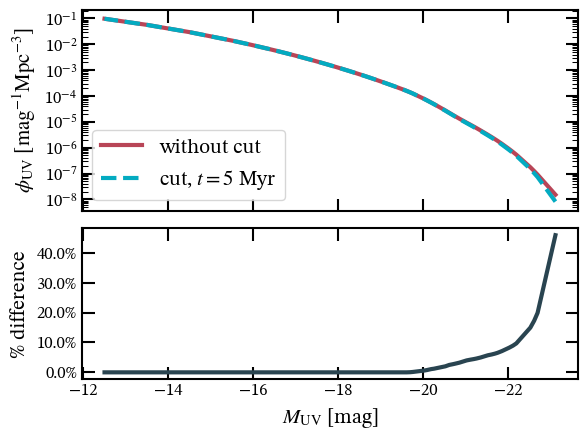

In [251]:
fig, axs = eplots.percent_diff(MUVcenters, comparison, test_5, labels = ['without cut', r'cut, $t=5$ Myr'])

axs[0].invert_xaxis()
axs[0].set_yscale('log')
axs[0].set_ylabel(r'$\phi_{\rm{UV}}$ [$\rm{mag}^{-1} \rm{Mpc}^{-3}$]')
axs[1].set_ylabel('% difference')
axs[1].set_xlabel(r'$M_{\rm{UV}}$ [mag]')


In [252]:
min_MUV_test = calc_min_MUV(my_UVLF.HMFintclass.Mhtab, 5e8, fb)
test, _, _  = UVLF_binned(my_UVLF, best_fit, 9, 0.5, MUVcenters, MUVwidths, min_MUV_test)

Text(0.5, 0, '$M_{\\rm{UV}}$ [mag]')

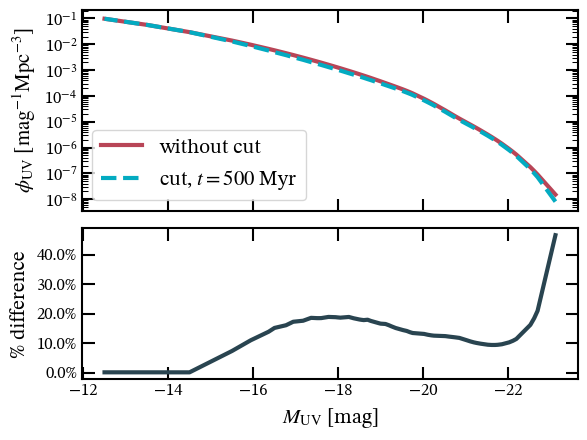

In [253]:
fig, axs = eplots.percent_diff(MUVcenters, comparison, test, labels = ['without cut', r'cut, $t = 500$ Myr'])

axs[0].invert_xaxis()
axs[0].set_yscale('log')
axs[0].set_ylabel(r'$\phi_{\rm{UV}}$ [$\rm{mag}^{-1} \rm{Mpc}^{-3}$]')
axs[1].set_ylabel('% difference')
axs[1].set_xlabel(r'$M_{\rm{UV}}$ [mag]')

In [254]:
fig.savefig('/Users/eb35267/Desktop/code/home/figures/uvlf_cut_500_Myr.png', bbox_inches='tight')

[0.94, -0.54, 11.7, -1.03, array([1.00000000e-04, 1.00000000e-04, 1.00000000e-04, 1.00000000e-04,
       1.00000000e-04, 1.00000000e-04, 1.00000000e-04, 1.00000000e-04,
       1.00000000e-04, 1.00000000e-04, 1.00000000e-04, 1.00000000e-04,
       1.00000000e-04, 1.00000000e-04, 1.00000000e-04, 1.00000000e-04,
       1.00000000e-04, 1.00000000e-04, 2.86294118e+00, 2.70588235e+00,
       2.54882353e+00, 2.39176471e+00, 2.23470588e+00, 2.07764706e+00,
       1.92058824e+00, 1.76352941e+00, 1.60647059e+00, 1.44941176e+00,
       1.29235294e+00, 1.13529412e+00, 9.78235294e-01, 8.21176471e-01,
       6.64117647e-01, 5.07058824e-01, 3.50000000e-01, 3.00000000e-01,
       3.00000000e-01, 3.00000000e-01, 3.00000000e-01, 3.00000000e-01,
       3.00000000e-01, 3.00000000e-01, 3.00000000e-01, 3.00000000e-01,
       3.00000000e-01, 3.00000000e-01, 3.00000000e-01, 3.00000000e-01,
       3.00000000e-01, 3.00000000e-01, 3.00000000e-01, 3.00000000e-01])]
[ -4.46115317  -4.90232964  -5.34350611  -5.7846

<>:13: SyntaxWarning: invalid escape sequence '\l'
<>:13: SyntaxWarning: invalid escape sequence '\l'
/var/folders/mm/m_9lg4t966qdjwf1r__0773r0000gq/T/ipykernel_53788/3303787942.py:13: SyntaxWarning: invalid escape sequence '\l'
  ax.set_title(f'$\log(M_h) = {round(np.log10(my_UVLF.HMFintclass.Mhtab)[i], 2)}$')


(-12.0, -24.0)

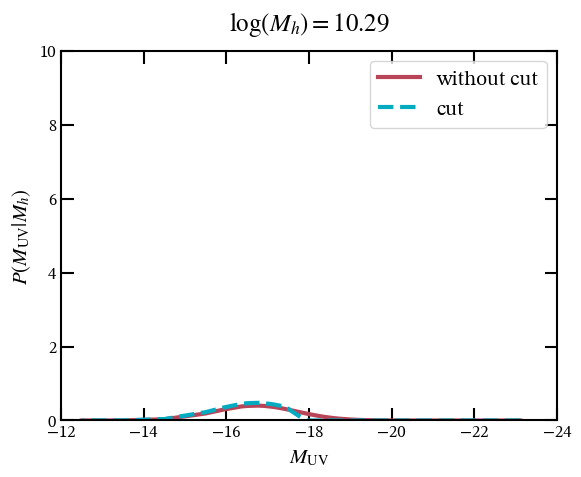

In [15]:
min_MUV_test = calc_min_MUV(my_UVLF.HMFintclass.Mhtab, 5e9, fb)
test, _, weights  = UVLF_binned(my_UVLF, best_fit, 9, 0.5, MUVcenters, MUVwidths, min_MUV_test)

i = 30

fig, ax = plt.subplots()
ax.set_ylabel(r'$P(M_{\rm{UV}}|M_h)$')
ax.set_xlabel(r'$M_{\rm{UV}}$')
ax.plot(MUVcenters, weights_og[i], label = 'without cut')
ax.plot(MUVcenters, weights[i], label = r'cut')
ax.invert_xaxis()

ax.set_title(f'$\log(M_h) = {round(np.log10(my_UVLF.HMFintclass.Mhtab)[i], 2)}$')

ax.legend()

ax.set_ylim(1e-10, 1e1)
ax.set_xlim(-12, -24)

# ax.set_yscale('log')

In [283]:
weights

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [1.85353682e-02, 1.74265934e-04, 5.81238010e-05, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [4.02410625e-03, 1.90398337e-05, 5.55865217e-06, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [6.80054125e-04, 1.60783134e-06, 4.10536601e-07, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00]])

In [285]:
len(my_UVLF.HMFintclass.Mhtab)

52

In [343]:
print(weights_5[20])

[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 1.30451792e-08 1.95125800e-07 3.34231896e-07 4.31627139e-07
 5.80335165e-07 7.64261586e-07 1.28223765e-06 1.43630924e-06
 1.66947777e-06 1.70105062e-06 1.97501353e-06 3.24563307e-06
 3.61892420e-06 4.18067459e-06 4.91175584e-06 6.63694199e-06
 7.90622295e-06 8.77505375e-06 1.00751352e-05 1.21634272e-05
 1.26705999e-05 1.79265683e-05 1.85343608e-05 2.04766554e-05
 2.37537014e-05 2.57819622e-05 2.79726773e-05 3.50766628e-05
 4.18143403e-05 5.72795087e-05 6.43524066e-05 6.79256406e-05
 8.80774108e-05 1.13702331e-04 1.22467797e-04 1.31858410e-04
 1.61831141e-04 2.11759075e-04 2.93824363e-04 3.71184186e-04
 5.33137827e-04 6.40418623e-04 1.09018540e-03 1.84897115e-03
 5.50022860e-03 1.40343464e-02 3.07160415e-02]


16


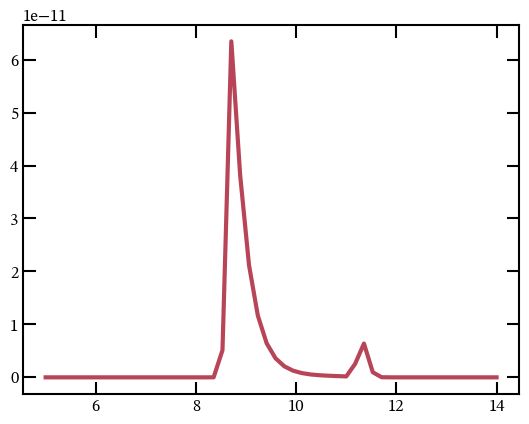

In [16]:
i = np.argmin(np.abs(MUVcenters + 21))
print(i)
Mhtab = my_UVLF.HMFintclass.Mhtab
hmf = my_UVLF.HMFintclass.HMF_int(Mhtab, 9)
PMh = hmf / np.trapz(hmf, Mhtab)  # prior normalized over Mh

# numerator of posterior
numerator = weights_5[:, i] * PMh

# normalization
norm = np.trapz(numerator, Mhtab)

posterior = numerator / norm
plt.plot(np.log10(Mhtab), posterior)

In [33]:
def PMh(best_fit, my_UVLF, MUV_range, z_range, Mhtab, zerr=0.5, ncols=3):
    """
    Plot P(Mh | M_UV) for a range of redshifts and MUVs.

    Parameters
    ----------
    param_values : array
        Parameter values for UVLF evolution
    my_UVLF : UVLF object
    MUV_range : array
        M_UV values to plot
    z_range : array
        Redshifts to plot
    MUV_widths : array, optional
        Widths of MUV bins
    z_err : array, optional
        Redshift Gaussian widths
    ncols : int
        Number of subplot columns
        
    """

    all_xdat = np.concatenate([
        np.concatenate([ds[2] for ds in z_separated])
        for z_separated in my_UVLF.sorted_data
    ])
    
    all_xerr = np.concatenate([
        np.concatenate([ds[6] for ds in z_separated])
        for z_separated in my_UVLF.sorted_data
    ])

    # Get unique x values and their corresponding errors
    MUVcenters, xdat_inds = np.unique(all_xdat, return_index=True)
    MUVwidths = all_xerr[xdat_inds]

    nz = len(z_range)
    fig = plt.figure()
    gs = GridSpec(math.ceil(nz / ncols), ncols, figure=fig)
    fig.set_size_inches(5*ncols, 4*math.ceil(nz/ncols))
    plt.subplots_adjust(wspace=0.3, hspace=0.3)

    # Colormap
    if len(MUV_range) > 1:
        cmap, sm, boundaries = eplots.create_custom_colorbar([eplots.orange, eplots.navy], MUV_range)

    Mhtab = my_UVLF.HMFintclass.Mhtab
    #my_UVLF.HMFintclass.Mhtab = Mhtab
    minMUV = my_UVLF.calc_min_MUV(Mhtab)

    axs = []


    for iz, z in enumerate(z_range): # Add the log likelihoods together for each redshift. The log likelihood is just a sum over all the points
        # anyways, so this makes sense

        ax = fig.add_subplot(gs[math.floor(iz/ncols), iz%ncols])
        axs.append(ax)

        ax.set_title(f'$z \simeq {z}$')

        weights = my_UVLF.UVLF_wrapper(z,zerr,MUVcenters, MUVwidths, best_fit, return_weights = True)

        # HMF prior (normalized)
        hmf = my_UVLF.HMFintclass.HMF_int(Mhtab, z)
        PMh = hmf / np.trapz(hmf, Mhtab)

        # Loop over MUV values for color-coded lines
        for MUV in MUV_range:

            iMUV = np.argmin(np.abs(MUVcenters-MUV))

            w1 = weights[:, iMUV]
            w2 = weights_5[:, i]


            return np.any(weights < 0), np.any(np.isnan(weights))


            PMUV_given_Mh = weights[:, iMUV]
            
            # numerator of Bayes theorem
            pMUV = PMUV_given_Mh * PMh 

            # normalize posterior
            posterior = pMUV /np.trapz(pMUV, Mhtab)

            # Color
            if len(MUV_range) > 1:
                frac = (MUV - min(MUV_range)) / (max(MUV_range) - min(MUV_range))
                color = cmap(frac)
            else:
                color = eplots.navy

            ax.plot(np.log10(Mhtab), posterior, color=color, ls='-')


    fig.text(0.06, 0.5, r'$p(M_h \mid M_{\rm UV})$', va='center', rotation='vertical', fontsize=17)
    fig.text(0.385, 0.05, r'$\log_{10} M_h / M_\odot$', va='center', fontsize=17)

    # Colorbar
    cbar = fig.colorbar(sm, ax=axs, boundaries=boundaries, ticks=MUV_range, aspect=4*math.ceil(nz/ncols))
    cbar.set_label(r'$M_{\rm{UV}}$')

    return fig



<>:60: SyntaxWarning: invalid escape sequence '\s'
<>:60: SyntaxWarning: invalid escape sequence '\s'
/var/folders/mm/m_9lg4t966qdjwf1r__0773r0000gq/T/ipykernel_53788/237741273.py:60: SyntaxWarning: invalid escape sequence '\s'
  ax.set_title(f'$z \simeq {z}$')


In [34]:
MUV_range = [-21]
z_range = [9]

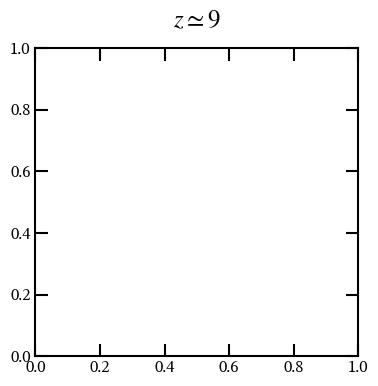

In [35]:
weights = PMh(best_fit, my_UVLF, MUV_range, z_range, Mhtab)

UnboundLocalError: cannot access local variable 'iMUV' where it is not associated with a value

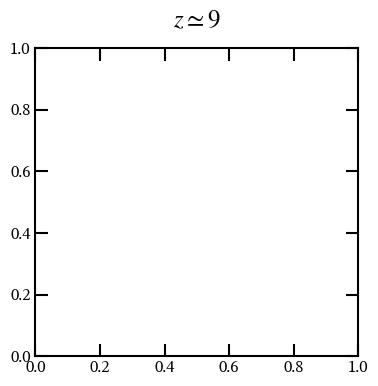

In [27]:
fig = PMh(best_fit, my_UVLF, MUV_range, z_range, Mhtab)